In [1]:
import sympy as sp

import itertools

In [2]:
x = sp.Symbol("x", real=True)
t = sp.Symbol("t",real=True, nonnegative=True)
y = sp.Function("y")

# 1

$$\langle x | x^3 \rangle \qquad x\in[0,1]$$

In [3]:
sp.integrate(x*x**3,(x,0,1))

1/5

# 2

$$\langle x^2 | x^3 \rangle \qquad x\in[-1,1]$$

In [4]:
sp.integrate(x**2*x**3,(x,-1,1))

0

# 3

$$\sqrt{\langle x^2 | x^2 \rangle} \qquad x\in[0,1]$$

In [5]:
sp.sqrt(sp.integrate(x**2*x**2,(x,0,1)))

sqrt(5)/5

# 4

$$\frac{\langle 1| x \rangle }{\langle x| x \rangle}\qquad x\in[0,2]$$

In [6]:
sp.integrate(1*x,(x,0,2))/sp.integrate(x*x,(x,0,2))

3/4

# 5

$$\{1,\cos(\pi x),\sin(\pi x)\}\qquad x\in[-1,1]$$

In [7]:

funciones = [1, sp.cos(sp.pi * x), sp.sin(sp.pi * x)]
limite_inferior = -1
limite_superior = 1

ortogonales = True

print("Verificando ortogonalidad:")
print("-" * 30)

for f1, f2 in itertools.combinations(funciones, 2):

    integral = sp.integrate(f1 * f2, (x, limite_inferior, limite_superior))
    
    print(f"Integral de ({f1}) * ({f2}) = {integral}")
    
    if integral != 0:
        ortogonales = False

print("-" * 30)
if ortogonales:
    print("¡El conjunto de funciones es ORTOGONAL!")
else:
    print("El conjunto de funciones NO es ortogonal.")

Verificando ortogonalidad:
------------------------------
Integral de (1) * (cos(pi*x)) = 0
Integral de (1) * (sin(pi*x)) = 0
Integral de (cos(pi*x)) * (sin(pi*x)) = 0
------------------------------
¡El conjunto de funciones es ORTOGONAL!


# 6

$$y'+3y=6e^{-2t}\qquad y(0)=0$$

In [8]:
eq = sp.Eq(y(t).diff(t)+3*y(t),6*sp.exp(-2*t))

condicionesIniciales = {y(0):0}

solucion = sp.dsolve(eq, y(t), ics=condicionesIniciales)

In [9]:
sp.expand(solucion)

Eq(y(t), 6*exp(-2*t) - 6*exp(-3*t))

# 7

$$y'+2y=4\sin(2t)\qquad y(0)=1$$

In [10]:
eq = sp.Eq(y(t).diff(t)+2*y(t), 4*sp.sin(2*t))
condicionesIniciales = {y(0):1}
solucion = sp.dsolve(eq, y(t), ics=condicionesIniciales)
sol = solucion.rhs

In [11]:
solucion

Eq(y(t), sin(2*t) - cos(2*t) + 2*exp(-2*t))

# 8

$$y'+y=3\cos(t)\qquad y(0)=2$$

In [12]:
eq = sp.Eq(y(t).diff(t)+y(t),3*sp.cos(t))
condicionesIniciales = {y(0):2}
solucion = sp.dsolve(eq, y(t), ics=condicionesIniciales)
sol = solucion.rhs

In [13]:
solucion

Eq(y(t), 3*sin(t)/2 + 3*cos(t)/2 + exp(-t)/2)

$$y''-5y'+6y=0\qquad y(0)=1,y'(0)=0$$

In [14]:
eq = sp.Eq(y(t).diff(t,2)-5*y(t).diff(t)+6*y(t),0)
condicionesIniciales = {
    y(0):1,
    y(t).diff(t).subs(t,0):0
}
solucion = sp.dsolve(eq,y(t),ics = condicionesIniciales)

In [15]:
solucion.expand()

Eq(y(t), -2*exp(3*t) + 3*exp(2*t))

In [16]:
eq = sp.Eq(y(t).diff(t,2)-y(t),2)
condicionesIniciales = {
    y(0):0,
    y(t).diff(t).subs(t,0):0
}
solucion = sp.dsolve(eq,y(t),ics = condicionesIniciales)
sol = solucion.rhs

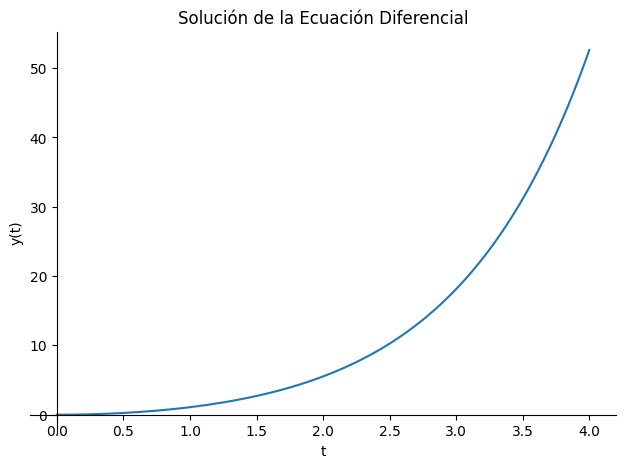

In [17]:
sp.plot(sol, (t, 0, 4), 
        title="Solución de la Ecuación Diferencial", 
        xlabel="t", 
        ylabel="y(t)");

In [18]:
sp.plotting.textplot(sol, 0, 4)

     53 |                                                      .
        |                                                       
        |                                                     . 
        |                                                    /  
        |                                                   /   
        |                                                  .    
        |                                                       
        |                                                 .     
        |                                               ..      
        |                                              /        
   26.5 |---------------------------------------------/---------
        |                                            /          
        |                                          ..           
        |                                        ..             
        |                                      ..               
        |                

In [19]:
t = sp.Symbol('t', real=True, nonnegative=True)
x1 = sp.Function('x1')(t)
x2 = sp.Function('x2')(t)
x3 = sp.Function('x3')(t)

# 2. Definir el sistema de ecuaciones diferenciales (Segunda ley de Newton)
# Ejemplo: Tres masas acopladas linealmente
eq1 = sp.Eq(x1.diff(t, 2), -2*x1 + x2)
eq2 = sp.Eq(x2.diff(t, 2), x1 - 2*x2 + x3)
eq3 = sp.Eq(x3.diff(t, 2), x2 - 2*x3)

sistema = [eq1, eq2, eq3]

# 3. Definir las condiciones iniciales (Posiciones y velocidades en t=0)
# Para mantener el código limpio, se usa un solo diccionario
condiciones = {
    x1.subs(t, 0): 1,   # Posición inicial x1
    x2.subs(t, 0): 0,   # Posición inicial x2
    x3.subs(t, 0): 0,   # Posición inicial x3
    x1.diff(t).subs(t, 0): 0,  # Velocidad inicial x1
    x2.diff(t).subs(t, 0): 0,  # Velocidad inicial x2
    x3.diff(t).subs(t, 0): 0   # Velocidad inicial x3
}

# 4. Resolver el sistema
soluciones = sp.dsolve(sistema, [x1, x2, x3], ics=condiciones)

In [20]:
for sol in soluciones:
    display(sol)
    print("\n")

Eq(x1(t), exp(I*t*sqrt(2 - sqrt(2)))/8 + sqrt(2)*sqrt(2 - sqrt(2))*sqrt(sqrt(2) + 2)*exp(I*t*sqrt(sqrt(2) + 2))/16 + cos(sqrt(2)*t)/2 + sqrt(2)*sqrt(2 - sqrt(2))*sqrt(sqrt(2) + 2)*exp(-I*t*sqrt(sqrt(2) + 2))/16 + exp(-I*t*sqrt(2 - sqrt(2)))/8)

Eq(x2(t), sqrt(2)*exp(I*t*sqrt(2 - sqrt(2)))/8 - sqrt(2 - sqrt(2))*(2*sqrt(2) + 3)*exp(I*t*sqrt(sqrt(2) + 2))/(4*(sqrt(2) + 2)**(3/2)) - sqrt(2 - sqrt(2))*(2*sqrt(2) + 3)*exp(-I*t*sqrt(sqrt(2) + 2))/(4*(sqrt(2) + 2)**(3/2)) + sqrt(2)*exp(-I*t*sqrt(2 - sqrt(2)))/8)

Eq(x3(t), exp(I*t*sqrt(2 - sqrt(2)))/8 + sqrt(2)*sqrt(2 - sqrt(2))*sqrt(sqrt(2) + 2)*exp(I*t*sqrt(sqrt(2) + 2))/16 - cos(sqrt(2)*t)/2 + sqrt(2)*sqrt(2 - sqrt(2))*sqrt(sqrt(2) + 2)*exp(-I*t*sqrt(sqrt(2) + 2))/16 + exp(-I*t*sqrt(2 - sqrt(2)))/8)